In [760]:
""" Imports and loading the data"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().parent
csv_path = PROJECT_ROOT / "archive" / "neo_v2.csv"
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
df.dtypes

print("Missing values per column:")
df.isnull().sum()   # Each cell 1 / 0 -> adds them together

Shape: (90836, 10)
Missing values per column:


id                    0
name                  0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
orbiting_body         0
sentry_object         0
absolute_magnitude    0
hazardous             0
dtype: int64

In [761]:
""" Change hazardous from (True/False) to (1/0)"""
df["hazardous_int"] = df["hazardous"].astype(int)
df = df.drop(columns=["hazardous"])  # (boolean) dropped, hazardous_int kept

print("Remaining columns:", list(df.columns))

Remaining columns: ['id', 'name', 'est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'orbiting_body', 'sentry_object', 'absolute_magnitude', 'hazardous_int']


In [762]:
""" Dropping non-informative columns """
print("Unique values in orbiting_body:", df["orbiting_body"].unique())  # Check for unique values
print("Unique values in sentry_object:", df["sentry_object"].unique())

drop_cols = ["id", "name"]
if df["orbiting_body"].nunique() == 1:  # Distinct value count, exclude Nan
    drop_cols.append("orbiting_body")
if df["sentry_object"].nunique() == 1:
    drop_cols.append("sentry_object")


df = df.drop(columns=drop_cols) # Removes columns from dataframe
print("Dropped columns:", drop_cols)
print("Remaining columns:", list(df.columns))

Unique values in orbiting_body: <StringArray>
['Earth']
Length: 1, dtype: str
Unique values in sentry_object: [False]
Dropped columns: ['id', 'name', 'orbiting_body', 'sentry_object']
Remaining columns: ['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude', 'hazardous_int']


In [763]:
""" Correlation """
numeric_cols_with_min =  ["est_diameter_min", "est_diameter_max",
                        "relative_velocity", "miss_distance", "absolute_magnitude"]

print("Correlation between est_diameter_min and est_diameter_max:",
      df["est_diameter_min"].corr(df["est_diameter_max"]))

print()
print("Correlation of each feature with the target:")
df[numeric_cols_with_min + ["hazardous_int"]].corr()["hazardous_int"]    # Pearsons correlation coefficient

Correlation between est_diameter_min and est_diameter_max: 0.9999999999999992

Correlation of each feature with the target:


est_diameter_min      0.183363
est_diameter_max      0.183363
relative_velocity     0.191185
miss_distance         0.042302
absolute_magnitude   -0.365267
hazardous_int         1.000000
Name: hazardous_int, dtype: float64

In [764]:
""" Drop est_diameter_min because of correlation with est_diameter_max"""
df = df.drop(columns=["est_diameter_min"])

numeric_cols = ["est_diameter_max", "relative_velocity", "miss_distance", "absolute_magnitude"]
print("Remaining columns:", list(df.columns))

Remaining columns: ['est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude', 'hazardous_int']


In [765]:
""" Summary of statistics"""
df[numeric_cols].describe()


,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,90836.000000,90836.000000,9.083600e+04,90836.000000
mean,0.284947,48066.918918,3.706655e+07,23.527103
std,0.667491,25293.296961,2.235204e+07,2.894086
min,0.001362,203.346433,6.745533e+03,9.230000
25%,0.043057,28619.020645,1.721082e+07,21.340000
50%,0.108153,44190.117890,3.784658e+07,23.700000
75%,0.320656,62923.604633,5.654900e+07,25.700000
max,84.730541,236990.128088,7.479865e+07,33.200000


In [766]:
""" Checking "ratio" between hazardous and non-hazardous"""
print(df["hazardous_int"].value_counts())  # Count how many times hazardous int appears
print()
print(df["hazardous_int"].value_counts(normalize=True) * 100)

hazardous_int
0    81996
1     8840
Name: count, dtype: int64

hazardous_int
0    90.268176
1     9.731824
Name: proportion, dtype: float64


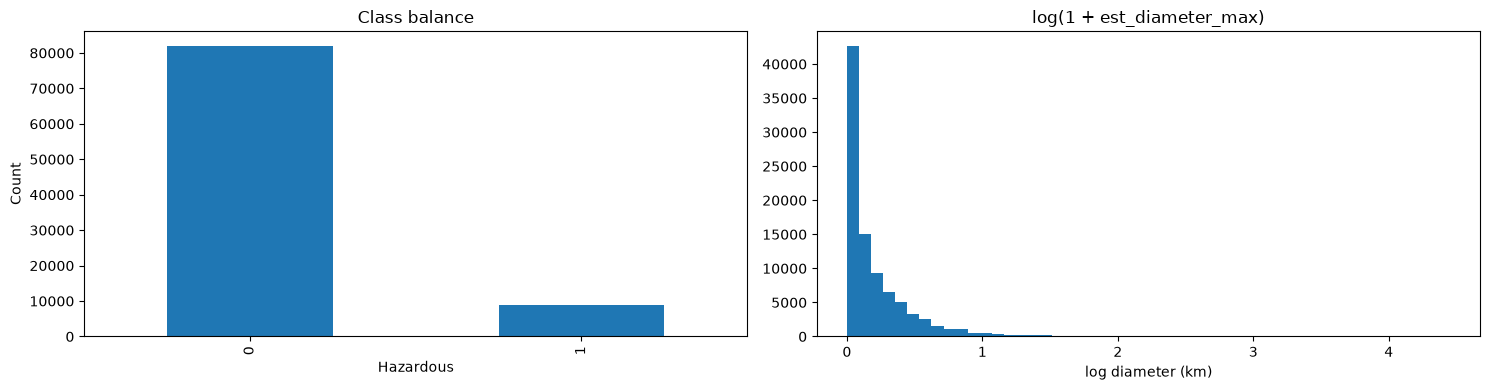

In [767]:
""" Visulaization """
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

df["hazardous_int"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Class balance")
axes[0].set_xlabel("Hazardous")
axes[0].set_ylabel("Count")

axes[1].hist(np.log1p(df["est_diameter_max"]), bins=50)
axes[1].set_title("log(1 + est_diameter_max)")
axes[1].set_xlabel("log diameter (km)")

plt.tight_layout()
plt.show()

In [768]:
""" Save output, figures and data """
df.to_csv("clean_data.csv", index = False)
fig.savefig("plot_overview.png", dpi = 150)

print("Shape of clean_data.csv:", df.shape)
print("Columns in clean_data.csv", list(df.columns))

Shape of clean_data.csv: (90836, 5)
Columns in clean_data.csv ['est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude', 'hazardous_int']


In [769]:
""" Splitting clean_data.csv to train/test data"""
clean_df = pd.read_csv("clean_data.csv")

print("Shape", clean_df.shape)
print("Columns:", list(clean_df.columns))

train_val_data, test_data = train_test_split(
    clean_df,
    test_size = 0.2,
    stratify=clean_df["hazardous_int"], # Splits hazardous_int evenly
    random_state=42   # Same split each time you run the cell
)

train_data, validation_data = train_test_split(
    train_val_data,
    test_size=0.2,
    stratify=train_val_data["hazardous_int"],
    random_state=42
)

print("\n")
train_data.to_csv("train_data.csv", index=False)
print("train_data.csv saved")
validation_data.to_csv("validation_data.csv", index=False)
print("validation_data.csv saved")
test_data.to_csv("test_data.csv", index=False)
print("test_data.csv saved")
print("\n")

Shape (90836, 5)
Columns: ['est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude', 'hazardous_int']


train_data.csv saved
validation_data.csv saved
test_data.csv saved




In [770]:
print("Train data shape", train_data.shape)
print(train_data["hazardous_int"].value_counts())
print(train_data["hazardous_int"].value_counts(normalize=True) * 100)
print("\n")
print("Validation data shape:", validation_data.shape)
print(validation_data["hazardous_int"].value_counts())
print(validation_data["hazardous_int"].value_counts(normalize=True) * 100)

Train data shape (58134, 5)
hazardous_int
0    52476
1     5658
Name: count, dtype: int64
hazardous_int
0    90.267313
1     9.732687
Name: proportion, dtype: float64


Validation data shape: (14534, 5)
hazardous_int
0    13120
1     1414
Name: count, dtype: int64
hazardous_int
0    90.271088
1     9.728912
Name: proportion, dtype: float64


In [771]:
print("\n")
print("Test data shape", test_data.shape)
print(test_data["hazardous_int"].value_counts())
print(test_data["hazardous_int"].value_counts(normalize=True) * 100)



Test data shape (18168, 5)
hazardous_int
0    16400
1     1768
Name: count, dtype: int64
hazardous_int
0    90.268604
1     9.731396
Name: proportion, dtype: float64


In [772]:
""" Libraries needed for Stage 2 """

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

In [773]:
""" Load train / validation / test data and scaling it """

train_data = pd.read_csv("train_data.csv")
validation_data = pd.read_csv("validation_data.csv")
test_data = pd.read_csv("test_data.csv")

feature_cols = ["est_diameter_max", "relative_velocity", "miss_distance", "absolute_magnitude"]

X_train = train_data[feature_cols]
y_train = train_data["hazardous_int"]

X_validation = validation_data[feature_cols]
y_validation = validation_data["hazardous_int"]

X_test = test_data[feature_cols]
y_test = test_data["hazardous_int"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_validation_scaled = scaler.transform(X_validation)
X_test_scaled = scaler.transform(X_test)
    # y data is boolean

In [774]:
""" Logistic Regression"""

model = LogisticRegression(class_weight='balanced')
model.fit(X_train_scaled, y_train)  # Finding weights and Biases

print("Logisitc Regression fitted")
print("Weights: ", model.coef_)
print("Bias: ", model.intercept_)

Logisitc Regression fitted
Weights:  [[-1.25631663  0.23611657 -0.36293133 -3.79788132]]
Bias:  [-2.20966639]


In [775]:
""" Prediction on validation set """
y_pred = model.predict(X_validation_scaled)
y_pred_train = model.predict(X_train_scaled)

Logisitc Regression Confusion matrix:
[[10065  3055]
 [  109  1305]]


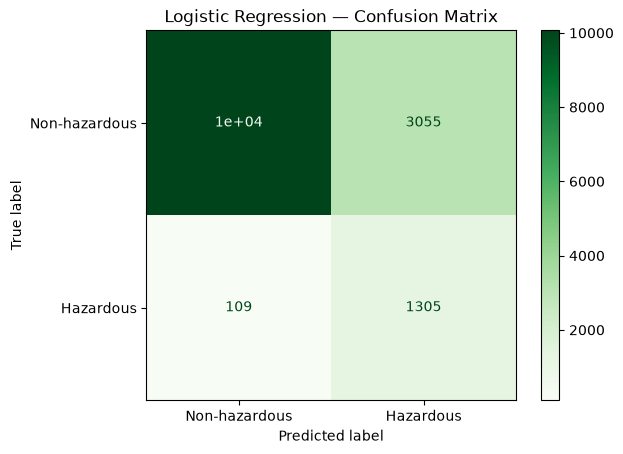

In [776]:
""" Confusion matrix of the Logisitc Regression """

cm = confusion_matrix(y_validation, y_pred)
print("Logisitc Regression Confusion matrix:")
print(cm)

# Visualization of the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-hazardous", "Hazardous"])
disp.plot(cmap="Greens") 
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

In [777]:
""" Validation confusion matrix analysis (Logisitic Regression) """

TN_LG = cm[0][0]
FP_LG = cm[0][1]
FN_LG = cm[1][0]
TP_LG = cm[1][1]

accuracy = (TP_LG + TN_LG) / (TP_LG + TN_LG + FP_LG + FN_LG)

if (TP_LG + FP_LG) > 0:
    precision = TP_LG / (TP_LG + FP_LG)
else:
    precision = 0

if (TP_LG + FN_LG) > 0:
    recall = TP_LG / (TP_LG + FN_LG)
else:
    recall = 0

if (precision + recall) > 0:
    f1 = 2 * (precision * recall) / (precision + recall)
else:
    f1 = 0

print("Validation metrics logistic regression")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Validation metrics logistic regression
Accuracy:  0.7823
Precision: 0.2993
Recall:    0.9229
F1-score:  0.4520


In [778]:
""" Training confusion matrix analysis (Logisitic Regression) """

cm_train = confusion_matrix(y_train, y_pred_train)

TN_train = cm_train[0][0]
FP_train = cm_train[0][1]
FN_train = cm_train[1][0]
TP_train = cm_train[1][1]

accuracy_train = (TP_train + TN_train)/(TP_train + TN_train + FP_train + FN_train)


if (TP_train + FP_train) > 0:
    precision_train = TP_train / (TP_train + FP_train)
else: precision_train = 0 

if (TP_train + FN_train) > 0:
    recall_train = TP_train / (TP_train + FN_train)
else: recall_train = 0

if (precision_train + recall_train) > 0:
    f1_train = 2 * (precision_train * recall_train) / (precision_train + recall_train)
else: f1_train = 0 

print("Training Metrics logistic regression") 
print(f"Accuracy:  {accuracy_train:.4f}")
print(f"Precision: {precision_train:.4f}")
print(f"Recall:    {recall_train:.4f}")
print(f"F1-score:  {f1_train:.4f}")

Training Metrics logistic regression
Accuracy:  0.7840
Precision: 0.3023
Recall:    0.9325
F1-score:  0.4566


In [779]:
""" Gradient Boosting """

GB_model = GradientBoostingClassifier(n_estimators=200,learning_rate=0.2,max_depth=5,random_state=42)
GB_model.fit(X_train, y_train)

y_pred_GB = GB_model.predict(X_validation)
y_pred_train_GB = GB_model.predict(X_train)



Gradient Boosting Confusion matrix
[[12937   183]
 [ 1041   373]]


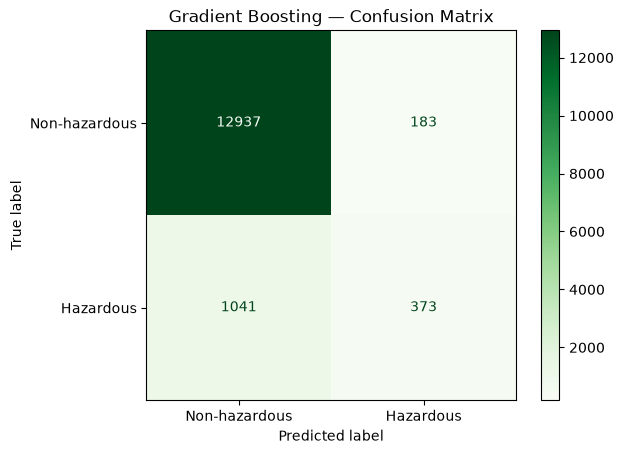

In [780]:
""" Validation confusion matrix of the Gradient Boosting """

cm_GB = confusion_matrix(y_validation, y_pred_GB)
print("Gradient Boosting Confusion matrix")
print(cm_GB)

disp_GB = ConfusionMatrixDisplay(confusion_matrix=cm_GB, display_labels=["Non-hazardous", "Hazardous"])
disp_GB.plot(cmap="Greens")
plt.title("Gradient Boosting — Confusion Matrix")
plt.show()

In [781]:
""" Confusion matrix analysis (Gradient Boosting) """

TN_GB = cm_GB[0][0]
FP_GB = cm_GB[0][1]
FN_GB = cm_GB[1][0]
TP_GB = cm_GB[1][1]

accuracy_GB = (TP_GB + TN_GB) / (TP_GB + TN_GB + FP_GB + FN_GB)

if (TP_GB + FP_GB) > 0:
    precision_GB = TP_GB / (TP_GB + FP_GB)
else:
    precision_GB = 0

if (TP_GB + FN_GB) > 0:
    recall_GB = TP_GB / (TP_GB + FN_GB)
else:
    recall_GB = 0

if (precision_GB + recall_GB) > 0:
    f1_GB = 2 * (precision_GB * recall_GB) / (precision_GB + recall_GB)
else:
    f1_GB = 0

print("Validation metrics gradient boosting")
print(f"Accuracy:  {accuracy_GB:.4f}")
print(f"Precision: {precision_GB:.4f}")
print(f"Recall:    {recall_GB:.4f}")
print(f"F1-score:  {f1_GB:.4f}")

Validation metrics gradient boosting
Accuracy:  0.9158
Precision: 0.6709
Recall:    0.2638
F1-score:  0.3787


In [782]:
""" Training confusion matrix analysis (Gradient boosting) """

cm_train_GB = confusion_matrix(y_train, y_pred_train_GB)

TN_train_GB = cm_train_GB[0][0]
FP_train_GB = cm_train_GB[0][1]
FN_train_GB = cm_train_GB[1][0]
TP_train_GB = cm_train_GB[1][1]

accuracy_train_GB = (TP_train_GB + TN_train_GB)/(TP_train_GB + TN_train_GB + FP_train_GB + FN_train_GB)


if (TP_train_GB + FP_train_GB) > 0:
    precision_train_GB = TP_train_GB / (TP_train_GB + FP_train_GB)
else: precision_train_GB = 0 

if (TP_train_GB + FN_train_GB) > 0:
    recall_train_GB = TP_train_GB / (TP_train_GB + FN_train_GB)
else: recall_train_GB = 0

if (precision_train_GB + recall_train_GB) > 0:
    f1_train_GB = 2 * (precision_train_GB * recall_train_GB) / (precision_train_GB + recall_train_GB)
else: f1_train_GB = 0 

print("Training Metrics GB") 
print(f"Accuracy:  {accuracy_train_GB:.4f}")
print(f"Precision: {precision_train_GB:.4f}")
print(f"Recall:    {recall_train_GB:.4f}")
print(f"F1-score:  {f1_train_GB:.4f}")

Training Metrics GB
Accuracy:  0.9397
Precision: 0.9138
Recall:    0.4198
F1-score:  0.5753


In [783]:
""" Logisitc Regression vs Gradient Boosting (Confusion matrix) """

print("\nComparison:")
print(f"{'Metric':<12}{'Logistic Reg':<15}{'Gradient Boost'}")
print(f"{'Accuracy':<12}{accuracy:<15.4f}{accuracy_GB:.4f}")
print(f"{'Precision':<12}{precision:<15.4f}{precision_GB:.4f}")
print(f"{'Recall':<12}{recall:<15.4f}{recall_GB:.4f}")
print(f"{'F1-score':<12}{f1:<15.4f}{f1_GB:.4f}")


Comparison:
Metric      Logistic Reg   Gradient Boost
Accuracy    0.7823         0.9158
Precision   0.2993         0.6709
Recall      0.9229         0.2638
F1-score    0.4520         0.3787


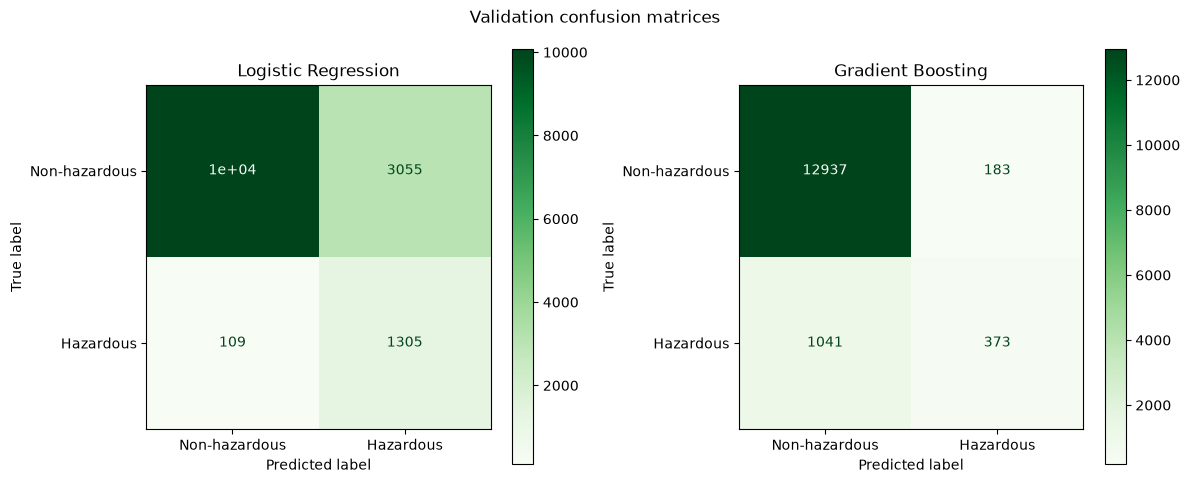

In [784]:
""" Validation confusion matrices """

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp.plot(ax=axes[0], cmap="Greens")
axes[0].set_title("Logistic Regression")

disp_GB.plot(ax=axes[1], cmap="Greens")
axes[1].set_title("Gradient Boosting")

plt.suptitle("Validation confusion matrices")
plt.tight_layout()
plt.show()

Logistic regression test results
Accuracy:  0.7858
Precision: 0.3043
Recall:    0.9338
F1-score:  0.4591


Logistic regression Confusion matrix
[[12626  3774]
 [  117  1651]]


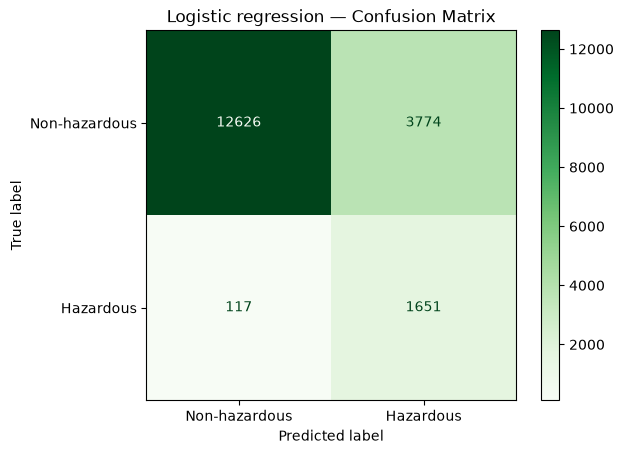

In [785]:
""" Using the model on our test data """

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_test_lr = model.predict(X_test_scaled)

print("Logistic regression test results")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_test_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_test_lr):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_test_lr):.4f}")
print("\n")

LR_cm_test = confusion_matrix(y_test, y_pred_test_lr)
print("Logistic regression Confusion matrix")
print(LR_cm_test)

cm_LR_disp = ConfusionMatrixDisplay(confusion_matrix=LR_cm_test, display_labels=["Non-hazardous", "Hazardous"])
cm_LR_disp.plot(cmap="Greens")
plt.title("Logistic regression — Confusion Matrix")
plt.show()




Gradient Boosting test results
Accuracy:  0.9200
Precision: 0.7209
Recall:    0.2907
F1-score:  0.4143


Logistic regression Confusion matrix
[[16201   199]
 [ 1254   514]]


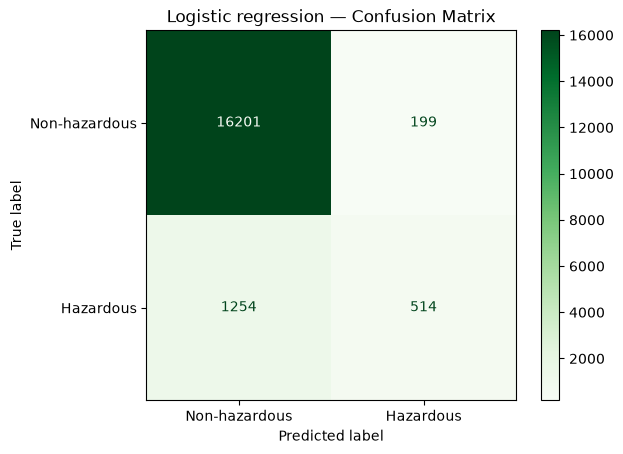

In [786]:
""" Using the model on our test data """

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# Gradient Boosting
y_pred_test_gb = GB_model.predict(X_test)

print("\nGradient Boosting test results")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_test_gb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test_gb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_test_gb):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_test_gb):.4f}")
print("\n")

GB_cm_test = confusion_matrix(y_test, y_pred_test_gb)
print("Logistic regression Confusion matrix")
print(GB_cm_test)

cm_GB_disp = ConfusionMatrixDisplay(confusion_matrix=GB_cm_test, display_labels=["Non-hazardous", "Hazardous"])
cm_GB_disp.plot(cmap="Greens")
plt.title("Logistic regression — Confusion Matrix")
plt.show()


Logistic Regression

                 Training       Test
---------------------------------------
TN               40302        12626
FP               12174        3774
FN               382          117
TP               5276         1651
---------------------------------------
Accuracy         0.7840       0.7858
Precision        0.3023       0.3043
Recall           0.9325       0.9338
F1-score         0.4566       0.4591


Gradient Boosting

                 Training       Test
---------------------------------------
TN               52252        16201
FP               224          199
FN               3283         1254
TP               2375         514
---------------------------------------
Accuracy         0.9397       0.9200
Precision        0.9138       0.7209
Recall           0.4198       0.2907
F1-score         0.5753       0.4143


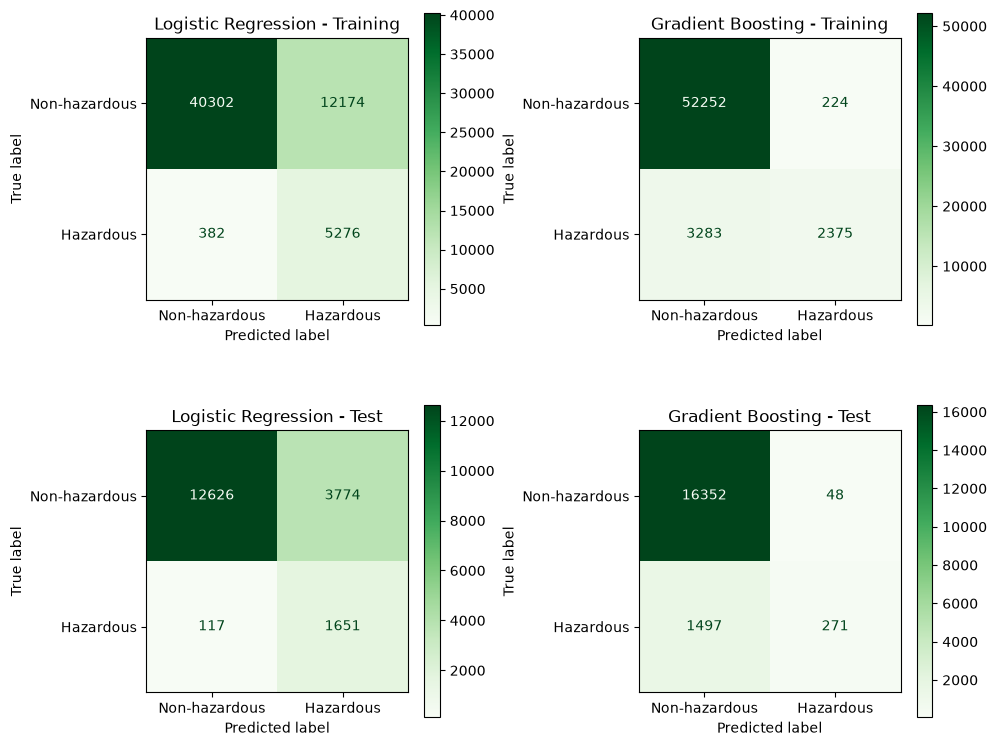

In [787]:
""" Comapring the training data to the test data """

cm_LR_train = confusion_matrix(y_train, y_pred_train)
LR_cm_test = confusion_matrix(y_test, y_pred_test_lr) #i used validation data i need to do this still for the actual test data

tn_LR_train, fp_LR_train, fn_LR_train, tp_LR_train = cm_LR_train.ravel()    # 2D -> 1 D
tn_LR_test, fp_LR_test, fn_LR_test, tp_LR_test = LR_cm_test.ravel()

accuracy_LR_train = (tp_LR_train + tn_LR_train) / (tp_LR_train + tn_LR_train + fp_LR_train + fn_LR_train)
precision_LR_train = tp_LR_train / (tp_LR_train + fp_LR_train)
recall_LR_train = tp_LR_train / (tp_LR_train + fn_LR_train)
f1_LR_train = 2 * precision_LR_train * recall_LR_train / (precision_LR_train + recall_LR_train)

accuracy_LR_test = (tp_LR_test + tn_LR_test) / (tp_LR_test + tn_LR_test + fp_LR_test + fn_LR_test)
precision_LR_test = tp_LR_test / (tp_LR_test + fp_LR_test)
recall_LR_test = tp_LR_test / (tp_LR_test + fn_LR_test)
f1_LR_test = 2 * precision_LR_test * recall_LR_test / (precision_LR_test + recall_LR_test)


cm_GB_train = confusion_matrix(y_train, y_pred_train_GB)
GB_cm_test = confusion_matrix(y_test, y_pred_test_gb)

tn_GB_train, fp_GB_train, fn_GB_train, tp_GB_train = cm_GB_train.ravel()    # 2D -> 1 D
tn_GB_test, fp_GB_test, fn_GB_test, tp_GB_test = GB_cm_test.ravel()

accuracy_GB_train = (tp_GB_train + tn_GB_train) / (tp_GB_train + tn_GB_train + fp_GB_train + fn_GB_train)
precision_GB_train = tp_GB_train / (tp_GB_train + fp_GB_train)
recall_GB_train = tp_GB_train / (tp_GB_train + fn_GB_train)
f1_GB_train = 2 * precision_GB_train * recall_GB_train / (precision_GB_train + recall_GB_train)

accuracy_GB_test = (tp_GB_test + tn_GB_test) / (tp_GB_test + tn_GB_test + fp_GB_test + fn_GB_test)
precision_GB_test = tp_GB_test / (tp_GB_test + fp_GB_test)
recall_GB_test = tp_GB_test / (tp_GB_test + fn_GB_test)
f1_GB_test = 2 * precision_GB_test * recall_GB_test / (precision_GB_test + recall_GB_test)


print("\nLogistic Regression\n")
print("                 Training       Test")
print("---------------------------------------")
print(f"TN               {tn_LR_train:<12} {tn_LR_test}")
print(f"FP               {fp_LR_train:<12} {fp_LR_test}")
print(f"FN               {fn_LR_train:<12} {fn_LR_test}")
print(f"TP               {tp_LR_train:<12} {tp_LR_test}")
print("---------------------------------------")
print(f"Accuracy         {accuracy_LR_train:<12.4f} {accuracy_LR_test:.4f}")
print(f"Precision        {precision_LR_train:<12.4f} {precision_LR_test:.4f}")
print(f"Recall           {recall_LR_train:<12.4f} {recall_LR_test:.4f}")
print(f"F1-score         {f1_LR_train:<12.4f} {f1_LR_test:.4f}")

print("\n\nGradient Boosting\n")
print("                 Training       Test")
print("---------------------------------------")
print(f"TN               {tn_GB_train:<12} {tn_GB_test}")
print(f"FP               {fp_GB_train:<12} {fp_GB_test}")
print(f"FN               {fn_GB_train:<12} {fn_GB_test}")
print(f"TP               {tp_GB_train:<12} {tp_GB_test}")
print("---------------------------------------")
print(f"Accuracy         {accuracy_GB_train:<12.4f} {accuracy_GB_test:.4f}")
print(f"Precision        {precision_GB_train:<12.4f} {precision_GB_test:.4f}")
print(f"Recall           {recall_GB_train:<12.4f} {recall_GB_test:.4f}")
print(f"F1-score         {f1_GB_train:<12.4f} {f1_GB_test:.4f}")


fig, axes = plt.subplots(2, 2, figsize=(10, 8))

labels = ["Non-hazardous", "Hazardous"]

# Training confusion matrices on the TOP row
ConfusionMatrixDisplay(
    cm_LR_train,
    display_labels=labels
).plot(ax=axes[0, 0], cmap="Greens", values_format="d")

axes[0, 0].set_title("Logistic Regression - Training")


ConfusionMatrixDisplay(
    cm_GB_train,
    display_labels=labels
).plot(ax=axes[0, 1], cmap="Greens", values_format="d")

axes[0, 1].set_title("Gradient Boosting - Training")


# Test confusion matrices on the BOTTOM row
ConfusionMatrixDisplay(
    cm_LR_test,
    display_labels=labels
).plot(ax=axes[1, 0], cmap="Greens", values_format="d")

axes[1, 0].set_title("Logistic Regression - Test")


ConfusionMatrixDisplay(
    cm_GB_test,
    display_labels=labels
).plot(ax=axes[1, 1], cmap="Greens", values_format="d")

axes[1, 1].set_title("Gradient Boosting - Test")


plt.tight_layout()
plt.show()